 
<img src="https://th.bing.com/th/id/R.3cd1c8dc996c5616cf6e65e20b6bf586?rik=09aaLyk4hfbBiQ&riu=http%3a%2f%2fcidics.uanl.mx%2fwp-content%2fuploads%2f2016%2f09%2fcimat.png&ehk=%2b0brgMUkA2BND22ixwLZheQrrOoYLO3o5cMRqsBOrlY%3d&risl=&pid=ImgRaw&r=0" 
     style="float: right; margin-right: 30px;" 
     width="120"
     />

---
 
# **PROCESAMIENTO DEL LENGUAJE NATURAL:** 

**EXAMEN 2.**
===
EZAU FARIDH TORRES TORRES.
     
<p align="right"> Maestría en Ciencias con Orientación en Matemáticas Aplicadas. </p>
<p align="right"> CENTRO DE INVESTIGACIÓN EN MATEMÁTICAS. </p>
<p align="right"> Fecha de entrega: 23-30/05/2025. </p>


---

In [1]:
# Necessary libraries. 
import numpy as np                                          # library for numerical operations.
import matplotlib.pyplot as plt                             # library for plotting.
import os                                                   # library for operating system.
import time                                                 # library for time.
from typing import (Tuple, Callable, List,                  # library for typing.
                    Optional, Union, Dict)                  # library for typing.
import pandas as pd                                         # library for data manipulation.
import emoji                                                # library for emoji handling.
import random                                               # library for random numbers.
import csv                                                  # library for csv operations.
import re                                                   # library for regular expressions.
import gc                                                   # library for garbage collection.
import xml.etree.ElementTree as ET                          # library for xml parsing.
from collections import (defaultdict, Counter)              # library for collections.
from tqdm import tqdm                                       # library for progress bar.
from colorama import Fore, Style                            # library for colored text.
import seaborn as sns                                       # library for data visualization.
sns.set_style("darkgrid")                                   # set style for seaborn.
import torch                                                # library for tensor operations.
import torch.nn as nn                                       # library for neural network operations.
import torch.nn.functional as F                             # library for functional operations.
from torch.utils.data import (DataLoader, Dataset)          # library for dataset.
from torch.nn.utils.rnn import pad_sequence                 # library for padding sequences.
from torch.optim import AdamW                               # library for optimizers.
from sklearn.metrics import (confusion_matrix,              # library for evaluation.
                             classification_report)         # library for evaluation.
from scipy.sparse import (csr_matrix, hstack)               # library for sparse matrices.
from transformers import (AutoTokenizer,                    # library for transformers.
                          AutoModel,                        # library for transformers.
                          get_scheduler,                    # library for schedulers.
                          get_cosine_schedule_with_warmup)  # library for transformers.
from torch.cuda.amp import (autocast, GradScaler)           # library for mixed precision training.
from sklearn.feature_extraction.text import TfidfVectorizer # library for TF-IDF.
gc.collect()                                                # garbage collection.
torch.cuda.empty_cache()                                    # clear CUDA cache.

# Reproducibility settings.
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Function to set device.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # set device to GPU if available, else CPU.

# **1.- Preprocesamiento de datos.**

## **1.1. Carga de datos.**

> Se implementa la función *load_data_by_user()* la cual carga los datos de entrenamiento, validación y test en diccionarios correspondientes:
> - *user_to_tweets*
> - *user_to_labels;*
>
> también la función *explore_users()*, con la cual se hace una exploración de los datos cargados y las funciones *clean_tweet()* y *clean_tweets_dict()* las cuales se usan para hacer una limpieza rápida de los tweets.
>
> **NOTA:** Dado que se usará el modelo *RoBERTuito* [<a href="#refs">1</a>], los autores recomiendan usar su método:
>```python
>from pysentimiento.preprocessing import preprocess_tweet
>```
>para la limpieza de datos, pero no mostró mejores resultados.

In [2]:
def load_data_by_user(folder_path: str, return_labels: bool = True
                      ) -> Union[Dict[str, List[str]], Tuple[Dict[str, List[str]], Dict[str, Tuple[str, str]]]]:
    """
    Load data and labels from the specified folder. This generates a dictionary mapping user IDs to lists of
    tweets. If return_labels is True, it also returns a dictionary mapping user IDs to tuples of labels.

    Parameters
    ----------
    folder_path : str
        Path to the folder containing XML files and a truth file.
    return_labels : bool, optional
        If True, return labels from the truth file. Default is True.
    
    Returns
    -------
    user_to_tweets : dict
        Dictionary mapping user IDs to lists of tweets.
    user_to_labels : dict, optional
        Dictionary mapping user IDs to tuples of labels. 
    """
    # Load labels from truth.txt of truth_order.txt.
    truth_file = 'truth.txt' if os.path.exists(os.path.join(folder_path, 'truth.txt')) else 'truth_order.txt'
    truth_path = os.path.join(folder_path, truth_file)

    if return_labels and not os.path.exists(truth_path):
        raise FileNotFoundError(f"Truth file not found in {folder_path}.")

    user_to_labels = {} # Dictionary to store the labels: user_id -> labels.
    if return_labels:
        with open(truth_path, 'r', encoding = 'utf-8') as f:         # Open the file.
            for line in f:                                           # Read the file line by line.
                user_id, gender, country = line.strip().split(':::') # Unpack the parts.
                user_to_labels[user_id] = (gender, country)          # Store the labels in the dictionary.

    # Load tweets from XML files.
    user_to_tweets = defaultdict(list)       # Dictionary to store the tweets: user_id -> list of tweets.
    for filename in os.listdir(folder_path): # Iterate over the files in the folder.
        if not filename.endswith('.xml'):    # Iterate over the XML files in the folder.
            continue
        user_id = filename.replace('.xml', '')          # Extract user ID from filename.
        file_path = os.path.join(folder_path, filename) # Construct the full file path.

        # Parse the XML file and extract the text.
        tree = ET.parse(file_path)
        root = tree.getroot()
        documents = root.find('documents')

        # Check if the documents element exists.
        if documents is None:
            continue
        for doc in documents.findall('document'):
            if doc.text:
                user_to_tweets[user_id].append(doc.text.strip())

    return (user_to_tweets, user_to_labels) if return_labels else user_to_tweets

def explore_users(user_to_tweets: Dict[str, List[str]], name: str) -> None:
    """
    Explore the data and print statistics.
    """
    tweet_counts = [len(tweets) for tweets in user_to_tweets.values()]
    print(f'➤ Stats for {name}')
    print(f'    Users count     : {len(user_to_tweets)}')
    print(f'    Total tweets    : {sum(tweet_counts)}')
    print(f'    Avg tweets/user : {np.mean(tweet_counts):.2f}')
    print(f'    Min tweets/user : {min(tweet_counts)}')
    print(f'    Max tweets/user : {max(tweet_counts)}\n')

def clean_tweet(text: str) -> str:
    """
    Clean the tweet text by removing unwanted characters and formatting.
    """
    text = re.sub(r"@\w+", "@usuario", text)            # Mentions → @usuario.
    text = re.sub(r"http\S+|www\.\S+|ftp\S+", "", text) # URLs → "".
    text = re.sub(r"#(\w+)", r"\1", text)               # Hashtags → word.
    text = re.sub(r"[^\w\s@áéíóúüñÁÉÍÓÚÜÑ]", "", text)  # Punctuation → "".
    text = re.sub(r"\s+", " ", text).strip()            # Extra spaces → " ".
    text = text.lower()                                 # Lowercase.
    return text

def clean_tweets_dict(user_to_tweets: Dict[str, List[str]]) -> Dict[str, List[str]]:
    """
    Clean the tweets in the dictionary by applying the clean_tweet function to each tweet.
    """
    return {
        user_id: [clean_tweet(tweet) for tweet in tweets]
        for user_id, tweets in user_to_tweets.items()
    }

> Se crean los diccionarios de los tres conjuntos de datos, así como los labels para entrenamiento y validación. Se limpian los datos y vemos que se cuenta con $3360$ usuarios para entrenamiento, $840$ para validación y $2800$ para test. Se asume que se tiene el directorio *data* en la que se encuentran los directorios *es_train*, *es_val* y *es_test* con los datos y archivos *'truth.txt'* y *'truth_order.txt'* 

In [ ]:
# Load data and labels for training, validation and testing.
user_to_tweets_train, user_to_labels_train = load_data_by_user(folder_path = './data/es_train')
user_to_tweets_val, user_to_labels_val = load_data_by_user(folder_path = './data/es_val')
user_to_tweets_test = load_data_by_user(folder_path = './data/es_test', return_labels = False)

# Clean the tweets in the dictionaries.
user_to_tweets_train = clean_tweets_dict(user_to_tweets_train)
user_to_tweets_val = clean_tweets_dict(user_to_tweets_val)
user_to_tweets_test = clean_tweets_dict(user_to_tweets_test)

genders = set(label[0] for label in user_to_labels_train.values())   # Get unique gender labels.
countries = set(label[1] for label in user_to_labels_train.values()) # Get unique country labels.
print(f'Number of genres    : {len(genders)}')
print(f'Number of countries : {len(countries)}')
print("")
print('Example of tweet')
user = 'f54e1a95965ea984606de6eec5d7cf32'
tweets = user_to_tweets_train[user]        
label = user_to_labels_train[user]               
print(f'User    : {user}')
print(f'Tweet   : {tweets[0]}')
print(f'Gender  : {label[0]}')           
print(f'Country : {label[1]}')         
print("")

# Explore the data for training and validation sets.
explore_users(user_to_tweets_train, 'Training')
explore_users(user_to_tweets_val, 'Validation')
explore_users(user_to_tweets_test, 'Test')

Number of genres    : 2
Number of countries : 7

Example of tweet
User    : f54e1a95965ea984606de6eec5d7cf32
Tweet   : se soltó el moño el loco trump pareciera que aquí en venezuela está prohibido ni mencionarlo medio extraño no el imperio mesmo
Gender  : male
Country : venezuela

➤ Stats for Training
    Users count     : 3360
    Total tweets    : 335998
    Avg tweets/user : 100.00
    Min tweets/user : 99
    Max tweets/user : 100

➤ Stats for Validation
    Users count     : 840
    Total tweets    : 84000
    Avg tweets/user : 100.00
    Min tweets/user : 100
    Max tweets/user : 100

➤ Stats for Test
    Users count     : 2800
    Total tweets    : 280000
    Avg tweets/user : 100.00
    Min tweets/user : 100
    Max tweets/user : 100



# **1.2.- Visualización de los datos.**

> Se revisa la distribución de los usuarios y de los tweets por género y país, concluyendo que los datos están muy bien balanceados.

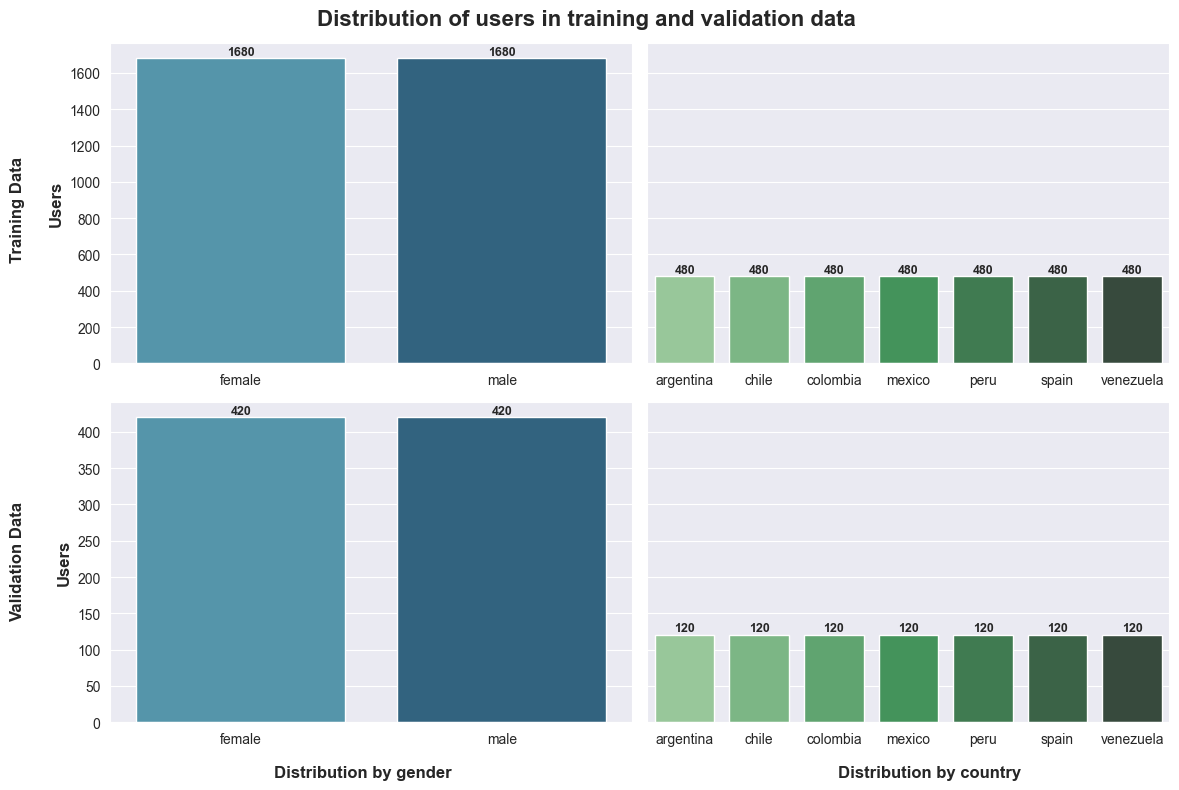

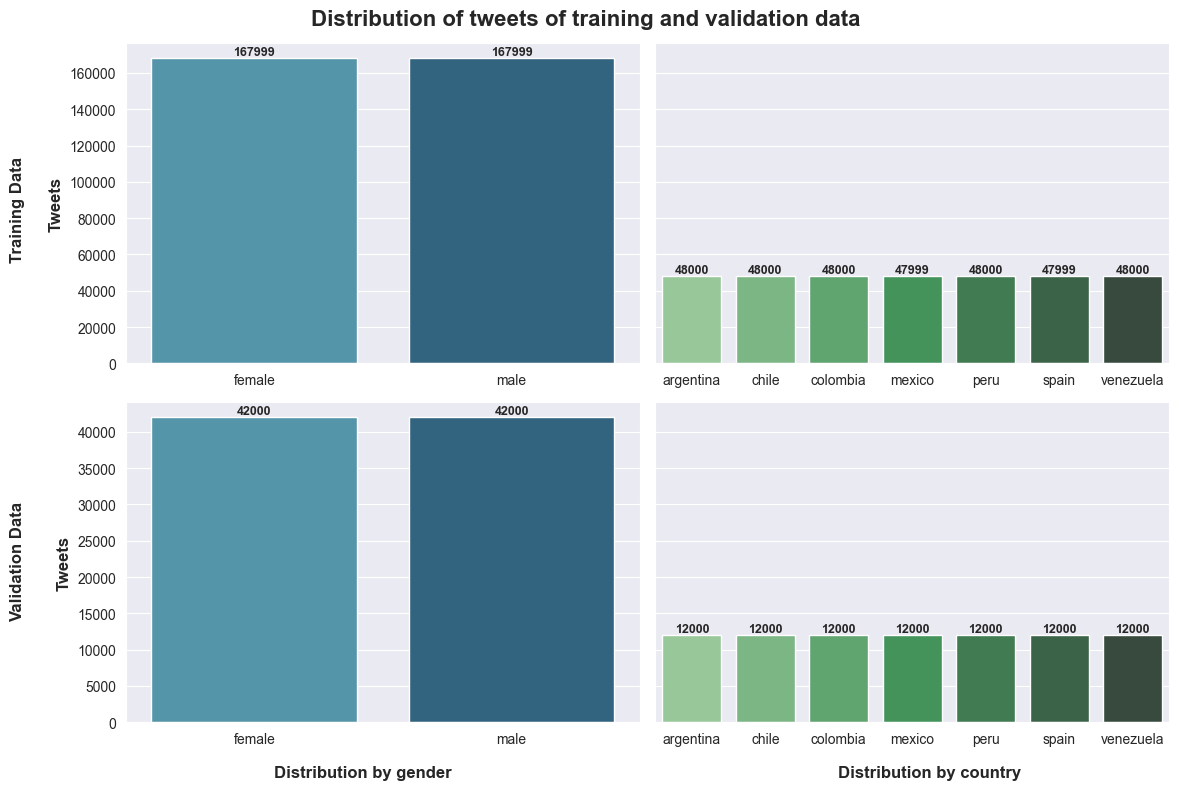

In [4]:
def plot_distribution(user_to_tweets_train: dict, user_to_tweets_val: dict,
                      user_to_labels_train: dict, user_to_labels_val: dict, plot_type: str) -> None:

    def annotate_bars(ax):
        for p in ax.patches:
            height = p.get_height()
            if not np.isnan(height) and height > 0:
                ax.text(p.get_x() + p.get_width() / 2., height + 1, int(height),
                        ha = "center", va = "bottom", fontsize = 9, weight = 'bold')

    fig, axs = plt.subplots(2, 2, figsize = (12,8), sharey = 'row')

    if plot_type == 'tweets':
        def expand_labels(user_to_tweets: dict, label_dict: dict) -> pd.DataFrame:
            data = []
            for user_id, tweets in user_to_tweets.items():
                if user_id in label_dict:
                    gender, country = label_dict[user_id]
                    for _ in tweets:
                        data.append((gender, country))
            return pd.DataFrame(data, columns = ["gender", "country"])

        df_train = expand_labels(user_to_tweets_train, user_to_labels_train)
        df_val   = expand_labels(user_to_tweets_val, user_to_labels_val)

        gender_order  = ['female', 'male']
        country_order = sorted(set(df_train['country']) | set(df_val['country']))

        fig.suptitle('Distribution of tweets of training and validation data', fontsize = 16, weight = 'bold')

        sns.countplot(data = df_train, x = "gender", hue = "gender", ax = axs[0,0], order = gender_order, hue_order = gender_order, palette = "YlGnBu_d")
        sns.countplot(data = df_train, x = "country", hue = "country", ax = axs[0,1], order = country_order, hue_order = country_order, palette = "Greens_d")
        sns.countplot(data = df_val,   x = "gender", hue = "gender", ax = axs[1,0], order = gender_order, hue_order = gender_order, palette = "YlGnBu_d")
        sns.countplot(data = df_val,   x = "country", hue = "country", ax = axs[1,1], order = country_order, hue_order = country_order, palette = "Greens_d")

        axs[0,0].set_ylabel("Tweets", fontsize = 12, weight = 'bold')
        axs[1,0].set_ylabel("Tweets", fontsize = 12, weight = 'bold')
        axs[0,1].set_ylabel("")
        axs[1,1].set_ylabel("")

    elif plot_type == 'users':
        df_train = pd.DataFrame(list(user_to_labels_train.values()), columns = ["gender", "country"])
        df_val   = pd.DataFrame(list(user_to_labels_val.values()),   columns = ["gender", "country"])

        gender_order  = ['female', 'male']
        country_order = sorted(set(df_train['country']) | set(df_val['country']))

        gender_counts_train  = df_train["gender"].value_counts().reindex(gender_order)
        gender_counts_val    = df_val["gender"].value_counts().reindex(gender_order)
        country_counts_train = df_train["country"].value_counts().reindex(country_order)
        country_counts_val   = df_val["country"].value_counts().reindex(country_order)

        fig.suptitle('Distribution of users in training and validation data', fontsize = 16, weight = 'bold')

        sns.barplot(x = gender_counts_train.index, y = gender_counts_train.values, hue = gender_counts_train.index, ax = axs[0,0], palette = "YlGnBu_d")  
        sns.barplot(x = country_counts_train.index, y = country_counts_train.values, hue = country_counts_train.index, ax = axs[0,1], palette = "Greens_d")
        sns.barplot(x = gender_counts_val.index, y = gender_counts_val.values, hue = gender_counts_val.index, ax = axs[1,0], palette = "YlGnBu_d")
        sns.barplot(x = country_counts_val.index, y = country_counts_val.values, hue = country_counts_val.index, ax = axs[1,1], palette = "Greens_d")

        axs[0,0].set_ylabel("Users", fontsize = 12, weight = 'bold')
        axs[1,0].set_ylabel("Users", fontsize = 12, weight = 'bold')
        axs[0,1].set_ylabel("")
        axs[1,1].set_ylabel("")

    else:
        raise ValueError("plot_type must be 'tweets' or 'users'.")

    for ax in axs.flatten():
        ax.set_xlabel("")
        annotate_bars(ax)

    fig.text(0.71, 0.02, 'Distribution by country', fontsize = 12, weight = 'bold')
    fig.text(0.24, 0.02, 'Distribution by gender', fontsize = 12, weight = 'bold')
    fig.text(0.02, 0.73, 'Training Data', va = 'center', rotation = 'vertical', fontsize = 12, weight = 'bold')
    fig.text(0.02, 0.29, 'Validation Data', va = 'center', rotation = 'vertical', fontsize = 12, weight = 'bold')

    plt.tight_layout(rect = [0.04, 0.04, 1, 1])
    plt.show()

plot_distribution(user_to_tweets_train, user_to_tweets_val, user_to_labels_train, user_to_labels_val, plot_type = 'users')
plot_distribution(user_to_tweets_train, user_to_tweets_val, user_to_labels_train, user_to_labels_val, plot_type = 'tweets')

# **2.- Dataset.**

>Se implementan tres elementos clave:
>1. **RobertuitoDataset**: es una clase de torch.utils.data.Dataset. Permite manejar datos jerárquicos por usuario, donde cada usuario tiene:
>   - Una lista de tweets tokenizados con un BERT preentrenado.
>   - Un vector TF-IDF combinado (caracteres + palabras).
>   - Un vector de características estadísticas calculadas a partir de sus tweets (longitud promedio, proporción de mayúsculas, emojis, puntuación, hashtags, palabras largas, etc.).
>   - Etiquetas opcionales de género y país.
>La clase soporta modo de prueba (is_test= . True), en cuyo caso solo devuelve todo sin etiquetas.
>2. **collate_fn_tfidf**: Función collate_fn personalizada que:
>   - Realiza el padding de secuencias de tweets tokenizados.
>   - Convierte los vectores TF-IDF a tensores PyTorch.
>   - Convierte las estadísticas de usuario a tensores.
>   - Agrupa las etiquetas (género, país) en tensores.
>Esto asegura que el batch final esté correctamente alineado para el modelo multitarea.
>3. **compute_tfidf_features**: Función que:
>   - Calcula las representaciones TF-IDF por usuario usando dos vectorizadores:
>   - vectorizer_char: n-gramas de caracteres ($1$ a $4$, estilo char_wb).
>   - vectorizer_word: n-gramas de palabras ($1$ a $4$).
>   - Combina ambas matrices (hstack) y regresa un diccionario user_to_tfidf que mapea IDs de usuario a sus vectores.
>   - También devuelve los vectorizadores usados, útil para transformar datos futuros con los mismos parámetros.
>4. **compute_user_stats**: Función que:
>   - Calcula, para cada usuario, estadísticas agregadas sobre sus tweets (longitud, proporción de mayúsculas, emojis, puntuación, hashtags, palabras largas, etc.).
>   - Devuelve un diccionario user_to_stats que mapea IDs de usuario a sus vectores de características (NumPy).
>
>El uso combinado de representaciones jerárquicas (tweets tokenizados), globales (TF-IDF) y estadísticas estructuradas (user stats) enriquece el modelo, permitiéndole capturar tanto patrones locales como patrones generales y estilísticos de escritura. Esto ha mostrado ser más efectivo que usar únicamente texto crudo.
>
>NOTA: Más información de cada método en su docstring.

In [5]:
class RobertuitoDataset(Dataset):
    def __init__(
            self, user_to_tweets: Dict[str, List[str]], user_to_labels: Optional[Dict[str, Tuple[str, str]]] = None,
            user_to_tfidf: Dict[str, torch.Tensor] = None, user_to_stats: Dict[str, np.ndarray] = None,
            tokenizer: AutoTokenizer = None, gender_to_id: Dict[str, int] = None, country_to_id: Dict[str, int] = None,
            max_tweets: int = 100, max_tokens: int = 64, is_test: bool = False
            ):
        """
        PyTorch Dataset for user-level tweet data enriched with TF-IDF and statistical features. This dataset
        prepares, for each user:
            - A batch of tokenized tweets (padded and truncated).
            - The corresponding TF-IDF vector.
            - The computed user-level statistical feature vector.
            - Labels for gender and country (if not in test mode).
        If used in test mode, the dataset returns the user ID instead of labels.

        Parameters
        ----------
        user_to_tweets : Dict[str, List[str]]
            Mapping from user IDs to their list of tweets.
        user_to_labels : Optional[Dict[str, Tuple[str, str]]]
            Mapping from user IDs to (gender, country) label pairs.
        user_to_tfidf : Dict[str, torch.Tensor]
            Mapping from user IDs to their TF-IDF feature vectors.
        user_to_stats : Dict[str, np.ndarray]
            Mapping from user IDs to their computed statistical feature vectors.
        tokenizer : AutoTokenizer
            Hugging Face tokenizer for processing tweets.
        gender_to_id : Dict[str, int]
            Mapping from gender labels to integer IDs.
        country_to_id : Dict[str, int]
            Mapping from country labels to integer IDs.
        max_tweets : int, optional
            Maximum number of tweets per user to consider (default: 100).
        max_tokens : int, optional
            Maximum number of tokens per tweet after tokenization (default: 64).
        is_test : bool, optional
            If True, dataset returns inputs + user ID without labels (default: False).
        """
        self.user_ids       = list(user_to_tweets.keys()) # List of user IDs.
        self.user_to_tweets = user_to_tweets              # Dictionary mapping user IDs to lists of tweets.
        self.user_to_labels = user_to_labels              # Dictionary mapping user IDs to tuples of labels.
        self.user_to_tfidf  = user_to_tfidf               # Dictionary mapping user IDs to TF-IDF vectors.
        self.user_to_stats = user_to_stats                # Dictionary mapping user IDs to statistical features.
        self.tokenizer      = tokenizer                   # Tokenizer for processing the tweets.
        self.gender_to_id   = gender_to_id                # Dictionary mapping gender labels to integer IDs. 
        self.country_to_id  = country_to_id               # Dictionary mapping country labels to integer IDs.
        self.max_tweets     = max_tweets                  # Maximum number of tweets per user to consider.
        self.max_tokens     = max_tokens                  # Maximum number of tokens per tweet after tokenization.
        self.is_test        = is_test                     # If True, the dataset is used for testing and does not return labels.
        self.id_to_gender   = {v: k for k, v in gender_to_id.items()}  # Inverse mapping from integer IDs to gender labels.
        self.id_to_country  = {v: k for k, v in country_to_id.items()} # Inverse mapping from integer IDs to country labels.

    def __len__(self) -> int:
        """
        Returns the number of users in the dataset.
        """
        return len(self.user_ids)

    def __getitem__(self, idx) -> Union[Dict[str, torch.Tensor], Tuple[Dict[str, torch.Tensor], int, int]]:
        """
        Retrieves the processed data for a specific user index. For a given user:
            - Tokenizes up to `max_tweets` tweets into input IDs and attention masks.
            - Retrieves the user's TF-IDF vector.
            - Retrieves the user's statistical feature vector.
            - If in test mode, returns the user ID alongside the input dictionary.
            - If in training/validation mode, returns integer-encoded gender and country labels.

        Parameters
        ----------
        idx : int
            Index of the user in the dataset.

        Returns
        -------
        If is_test is True:
            Tuple[dict, str]
                - dict: {
                    'input_ids': Tensor (max_tweets, max_tokens),
                    'attention_mask': Tensor (max_tweets, max_tokens),
                    'tfidf': Tensor or sparse matrix (num_features,),
                    'user_stats': Tensor (num_stats,)
                }
                - user_id: str
        If is_test is False:
            Tuple[dict, int, int]
                - dict: same as above.
                - gender_id: int
                - country_id: int
        """
        user_id = self.user_ids[idx]                            # Get the user ID for the current index.
        tweets = self.user_to_tweets[user_id][:self.max_tweets] # Limit the number of tweets to max_tweets.

        # Tokenize the tweets using the provided tokenizer.
        tokenized = [self.tokenizer(tweet, truncation = True, padding = 'max_length',
                                    max_length = self.max_tokens, return_tensors = 'pt')
                                    for tweet in tweets]

        input_ids = torch.stack([t['input_ids'].squeeze(0) for t in tokenized])      # Stack input IDs from tokenized tweets.
        attn_mask = torch.stack([t['attention_mask'].squeeze(0) for t in tokenized]) # Stack attention masks from tokenized tweets.
        tfidf_tensor = self.user_to_tfidf[user_id]                                   # Get the TF-IDF vector for the user.

        if isinstance(tfidf_tensor, torch.Tensor):
            tfidf_tensor = tfidf_tensor
        else:
            tfidf_tensor = torch.tensor(tfidf_tensor.toarray().squeeze(), dtype = torch.float32)

        # Ensure the TF-IDF tensor has the correct shape.
        user_stats = torch.tensor(self.user_to_stats[user_id], dtype = torch.float32)

        # If the dataset is for testing, return only the input data.
        if self.is_test:
            return {'input_ids': input_ids,'attention_mask': attn_mask,'tfidf': tfidf_tensor,'user_stats': user_stats}, user_id

        gender_id = self.gender_to_id[self.user_to_labels[user_id][0]]
        country_id = self.country_to_id[self.user_to_labels[user_id][1]]

        # Return the input data along
        return {'input_ids': input_ids,'attention_mask': attn_mask,'tfidf': tfidf_tensor,'user_stats': user_stats}, gender_id, country_id

def collate_fn_tfidf(batch: List[Union[Dict[str, torch.Tensor], Tuple[Dict[str, torch.Tensor], int, int]]]) -> Tuple[Dict[str, torch.Tensor], torch.Tensor, torch.Tensor]:
    """
    Custom collate function for batching user tweet data with TF-IDF and statistical features. This function:
        - Pads the input IDs and attention masks across the batch.
        - Stacks the TF-IDF feature vectors.
        - Stacks the user-level statistical feature vectors.
        - Aggregates the gender and country labels into tensors.

    Parameters
    ----------
    batch : list of tuples
        Each item is a tuple of (inputs, gender, country), where:
            - inputs: dict with keys 'input_ids', 'attention_mask', 'tfidf', 'user_stats'.
            - gender: int (integer-encoded gender label).
            - country: int (integer-encoded country label).

    Returns
    -------
    Tuple[dict, torch.Tensor, torch.Tensor]
        A tuple where:
            - dict contains batched 'input_ids', 'attention_mask', 'tfidf', 'user_stats'.
            - gender tensor (batch_size,).
            - country tensor (batch_size,).
    """
    batch_input_ids, batch_attn_masks, batch_tfidf, batch_user_stats = [], [], [], []
    genders, countries = [], []

    for (inputs, gender, country) in batch:
        batch_input_ids.append(inputs['input_ids'])
        batch_attn_masks.append(inputs['attention_mask'])
        batch_tfidf.append(inputs['tfidf'])
        batch_user_stats.append(inputs['user_stats'])

        genders.append(gender)
        countries.append(country)

    input_ids = pad_sequence(batch_input_ids, batch_first = True, padding_value = 0)
    attention_mask = pad_sequence(batch_attn_masks, batch_first = True, padding_value = 0)
    tfidf_tensor = torch.stack(batch_tfidf).to(input_ids.device)
    user_stats_tensor = torch.stack(batch_user_stats).to(input_ids.device)

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'tfidf': tfidf_tensor,
        'user_stats': user_stats_tensor
    }, torch.tensor(genders), torch.tensor(countries)

def compute_tfidf_features(
        user_to_tweets: Dict[str, List[str]], vectorizer_char: TfidfVectorizer = None,
        vectorizer_word: TfidfVectorizer = None) -> Tuple[Dict[str, torch.Tensor], Tuple[TfidfVectorizer, TfidfVectorizer]]:
    """
    Computes combined TF-IDF feature vectors for each user, using character n-grams and word n-grams. If
    vectorizers are not provided, new ones are initialized and fitted to the data.

    Parameters
    ----------
    user_to_tweets : dict
        Dictionary mapping user IDs (str) to lists of tweets (List[str]).
    vectorizer_char : TfidfVectorizer, optional
        TfidfVectorizer instance for character n-grams.
        If None, a new vectorizer is created and fitted.
    vectorizer_word : TfidfVectorizer, optional
        TfidfVectorizer instance for word n-grams.
        If None, a new vectorizer is created and fitted.

    Returns
    -------
    Tuple[dict, Tuple[TfidfVectorizer, TfidfVectorizer]]
        - user_to_tfidf: Dictionary mapping user IDs (str) to combined TF-IDF vectors.
        - vectorizers: Tuple containing the fitted character and word TfidfVectorizer instances.
    """
    user_ids = list(user_to_tweets.keys())
    docs = [" ".join(user_to_tweets[uid]) for uid in user_ids]

    if vectorizer_char is None:
        vectorizer_char = TfidfVectorizer(ngram_range = (1,4), analyzer = 'char_wb', max_features = 10000)
        X_char = vectorizer_char.fit_transform(docs)
    else:
        X_char = vectorizer_char.transform(docs)

    if vectorizer_word is None:
        vectorizer_word = TfidfVectorizer(ngram_range = (1,4), analyzer = 'word', max_features = 10000)
        X_word = vectorizer_word.fit_transform(docs)
    else:
        X_word = vectorizer_word.transform(docs)

    X_combined = hstack([X_char, X_word])
    user_to_tfidf = {uid: X_combined[i] for i, uid in enumerate(user_ids)}

    return user_to_tfidf, (vectorizer_char, vectorizer_word)

def compute_user_stats(user_to_tweets: Dict[str, List[str]]) -> Dict[str, np.ndarray]:
    """
    Computes aggregated statistical features for each user based on their tweets. For each user, the
    function calculates per-tweet features:
        - Average tweet length (number of characters).
        - Average proportion of uppercase letters.
        - Average proportion of emojis or non-alphanumeric symbols.
        - Average count of exclamation and question marks.
        - Average proportion of hashtags relative to word count.
        - Average proportion of long words (words longer than 7 characters).

    Parameters
    ----------
    user_to_tweets : Dict[str, List[str]]
        Dictionary mapping user IDs to their list of tweets.

    Returns
    -------
    Dict[str, np.ndarray]
        Dictionary mapping user IDs to a NumPy array (float32) with the aggregated
        feature values in the order:
        [length, caps, emojis, punctuation, hashtags, long_words].
    """
    def extract_features(tweet: str) -> Dict[str, float]:
        n = len(tweet)
        words = tweet.split()
        return {
            "len"        : n,
            "caps"       : sum(c.isupper() for c in tweet) / max(n, 1),
            "emojis"     : len(re.findall(r"[^\w\s,]", tweet)) / max(n, 1),
            "punc"       : tweet.count('!') + tweet.count('?'),
            "hashtags"   : tweet.count('#') / max(len(words), 1),
            "long_words" : sum(len(w) > 7 for w in words) / max(len(words), 1)
        }

    user_to_stats = {}
    for uid, tweets in user_to_tweets.items():
        feats = [extract_features(t) for t in tweets]
        user_feat = {
            k: np.mean([f[k] for f in feats]) for k in feats[0]
        }
        user_to_stats[uid] = np.array(list(user_feat.values()), dtype = np.float32)
    return user_to_stats


def load_test_user_order(truth_file_path: str) -> List[str]:
    """
    Load the order of user IDs from the truth file for the test set. The truth file contains user IDs
    and their corresponding labels.
    """
    with open(truth_file_path, 'r', encoding='utf-8') as f:
        return [line.strip().split(":::")[0] for line in f]
ordered_user_ids = load_test_user_order("./data/es_test/truth_order.txt")

## **2.1.- Configuración del modelo.**

> Se define el modelo base (*RoBERTuito*) y se carga el tokenizer correspondiente usando *HuggingFace*.
>
> Se calculan los vectores *TF-IDF*:
> - En el set de entrenamiento, se ajustan (fit) los dos vectorizadores (caracteres y palabras).
> - En los sets de validación y prueba, se reutilizan los mismos vectorizadores entrenados previamente para evitar fuga de información.
>
> Se calculan las estadísticas por usuario y se construyen los diccionarios de mapeo:
> - *gender_to_id*: asigna un ID entero a cada género.
> - *country_to_id*: asigna un ID entero a cada país.
>
> **NOTA:** La tarea se intentó con muchas versiones de *Bert* y *RoBERTa*, tanto multilingüe como en español, pero *RoBERTuito* fue el que mostró mejores resultados.

In [6]:
model_name = "pysentimiento/robertuito-base-uncased"  # Model name for the tokenizer.
tokenizer = AutoTokenizer.from_pretrained(model_name) # Load the tokenizer from the specified model.

# Compute TF-IDF features and user statistics for training, validation, and test sets.
user_to_tfidf_train, (vectorizer_char, vectorizer_word) = compute_tfidf_features(user_to_tweets_train)
user_to_tfidf_val, _ = compute_tfidf_features(user_to_tweets_val, vectorizer_char, vectorizer_word)
user_to_tfidf_test, _ = compute_tfidf_features(user_to_tweets_test, vectorizer_char, vectorizer_word)

# Convert TF-IDF features to PyTorch tensors.
user_to_stats_train = compute_user_stats(user_to_tweets_train)
user_to_stats_val   = compute_user_stats(user_to_tweets_val)
user_to_stats_test  = compute_user_stats(user_to_tweets_test)

# Reorder the user IDs in the test set to match the order in truth_order.txt.
user_to_tweets_test = {uid: user_to_tweets_test[uid] for uid in ordered_user_ids}
user_to_tfidf_test  = {uid: user_to_tfidf_test[uid]  for uid in ordered_user_ids}
user_to_stats_test  = {uid: user_to_stats_test[uid]  for uid in ordered_user_ids}

# Create the mappings for gender and country labels to integer IDs.
gender_to_id = {gender: idx for idx, gender in enumerate(sorted(genders))}
country_to_id = {country: idx for idx, country in enumerate(sorted(countries))}
print("Gender Map  :", gender_to_id)
print("Country Map :", country_to_id)

Gender Map  : {'female': 0, 'male': 1}
Country Map : {'argentina': 0, 'chile': 1, 'colombia': 2, 'mexico': 3, 'peru': 4, 'spain': 5, 'venezuela': 6}


>Se eligieron $100$ como el número máximo de tweets a ser considerados por usuario (todos los disponibles) y $64$ como número máximo de tokens a considerar por tweet, dado que el percentil $99$ de las longitudes de los tweets en el conjunto de entrenamiento es $45$.
>
>A continuación, se crean los Datasets y Dataloaders usando un tamaño de batch de $8$ (también se intentaron diversas configuraciones de hiperparámetros pero estas fueron soportadas por la GPU y dieron buenos resultados).

In [7]:
max_tweets = 100 # Maximum number of tweets per user to consider.
max_tokens = 64  # Maximum number of tokens per tweet after tokenization.
batch_size = 8   # Batch size for DataLoader.

# Create the datasets for training, validation, and testing.
train_dataset = RobertuitoDataset(
    user_to_tweets = user_to_tweets_train, user_to_labels = user_to_labels_train,
    user_to_tfidf = user_to_tfidf_train, user_to_stats = user_to_stats_train,
    tokenizer = tokenizer, gender_to_id = gender_to_id, country_to_id = country_to_id,
    max_tweets = max_tweets, max_tokens = max_tokens
)
val_dataset = RobertuitoDataset(
    user_to_tweets = user_to_tweets_val, user_to_labels = user_to_labels_val,
    user_to_tfidf = user_to_tfidf_val, user_to_stats = user_to_stats_val,
    tokenizer = tokenizer, gender_to_id = gender_to_id, country_to_id = country_to_id,
    max_tweets = max_tweets, max_tokens = max_tokens
)
test_dataset = RobertuitoDataset(
    user_to_tweets = user_to_tweets_test, user_to_tfidf = user_to_tfidf_test,
    user_to_stats = user_to_stats_test, tokenizer = tokenizer, gender_to_id = gender_to_id,
    country_to_id = country_to_id, max_tweets = max_tweets, max_tokens = max_tokens, is_test = True
)

# Create DataLoaders for training, validation, and testing datasets.
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, collate_fn = collate_fn_tfidf)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False, collate_fn = collate_fn_tfidf)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False, collate_fn = collate_fn_tfidf)

# **3.- Modelo.**

>El modelo CrossAttentionBidirectionalModel es un clasificador multitarea diseñado para predecir género y país de usuarios en redes sociales, integrando múltiples tipos de representación:
>- Codificaciones jerárquicas de tweets usando un backbone RoBERTa preentrenado.
>- Representaciones globales basadas en TF-IDF, tratadas como secuencias divididas y pasadas por un transformer especializado.
>- Estadísticas estructuradas del usuario (longitud promedio de tweets, uso de mayúsculas, puntuación, etc.) proyectadas al espacio de embeddings.
>
>El modelo combina estas representaciones mediante mecanismos de atención bidireccional (cross-attention) entre los espacios de tweet, TF-IDF y usuario, incluyendo un módulo de atención tipo HAN para capturar la importancia relativa de los tweets. Finalmente, concatena todas las salidas y pasa por clasificadores separados para cada tarea.
>
>**NOTA:** De nuevo, se intentó una gran cantidad de arquitecturas y configuraciones, pero con esta se logró el accuracy conjunto de ~$0.83$ mostrado en Kaggle.

In [8]:
class HANAttention(nn.Module):
    """
    HANAttention is an attention module inspired by the Hierarchical Attention Network (HAN). It applies:
        - A linear transformation with tanh activation over the input.
        - A learned context vector to compute importance weights over the sequence.
        - A weighted sum over the sequence based on these learned attention weights.
    This module is typically used to collapse a sequence of embeddings into a single contextualized embedding
    by focusing on the most relevant parts.

    Parameters
    ----------
    hidden_size : int
        Dimensionality of the input and output hidden representations.
    """
    def __init__(self, hidden_size: int):
        super().__init__()
        self.linear = nn.Linear(hidden_size, hidden_size)
        self.context = nn.Parameter(torch.randn(hidden_size))

    def forward(self, x):                                           # (B, T, H)
        """
        Computes the attention-weighted summary of the input sequence.
        
        Parameters
        ----------
        x : Tensor
            Input tensor of shape (B, T, H), where:
            - B: batch size.
            - T: sequence length.
            - H: hidden size.
        
        Returns
        -------
        Tensor
            Attention-weighted summary tensor of shape (B, H).
        """
        u = torch.tanh(self.linear(x))                              # (B, T, H)
        weights = F.softmax(torch.matmul(u, self.context), dim = 1) # (B, T)
        return (x * weights.unsqueeze(-1)).sum(1)                   # (B, H)

class CrossAttentionBidirectionalModel(nn.Module):
    def __init__(self, model_name: str, hidden_size: int, num_classes_gender: int = 2, num_classes_country: int = 7,
                 tfidf_dim: int = 20000, tfidf_proj_dim: int = 768, tfidf_token_dim: int = 160, user_feat_dim: int = 6, dim_feedforward: int = 2048,
                 num_heads: int = 12, num_layers: int = 4):
        """
        CrossAttentionBidirectionalModel is a multitask classification model that integrates hierarchical tweet
        encodings, TF-IDF representations, and user-level statistical features. It combines:
            - RoBERTa-based token-level encodings per tweet.
            - A transformer over tweet sequences.
            - A HAN-style self-attention mechanism across tweets.
            - TF-IDF projected as token-like sequences passed through a transformer.
            - User-level handcrafted features projected to the embedding space.
            - Multiple cross-attention layers that fuse the tweet, TF-IDF, and user embeddings.
        
        Parameters
        ----------
        model_name : str
            Name of the pretrained Hugging Face model.
        hidden_size : int
            Size of the hidden layers.
        num_classes_gender : int
            Number of gender classes.
        num_classes_country : int
            Number of country classes.
        tfidf_dim : int, optional
            Input dimensionality of the TF-IDF vector (default: 20000).
        tfidf_proj_dim : int, optional
            Output projection dimension of the TF-IDF sequence (default: 768).
        tfidf_token_dim : int, optional
            Dimensionality of each token in the TF-IDF split (default: 160).
        num_heads : int, optional
            Number of attention heads in cross-attention (default: 8).
        num_layers : int, optional
            Number of transformer layers for the tweet encoder (default: 4).
        """
        super().__init__()
        self.roberta = AutoModel.from_pretrained(model_name)
        roberta_hidden_size = self.roberta.config.hidden_size

        # Transformers encoder for tweets.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model = roberta_hidden_size, nhead = num_heads,
            dim_feedforward = dim_feedforward, activation = 'gelu', batch_first = True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers = num_layers)
        self.norm_transformer = nn.LayerNorm(roberta_hidden_size)
        self.norm_tweet = nn.LayerNorm(roberta_hidden_size)
        self.dropout = nn.Dropout(0.3)
        self.han = HANAttention(hidden_size)

        # TF-IDF features processing.
        self.tfidf_token_dim = tfidf_token_dim
        self.num_tfidf_tokens = tfidf_dim // tfidf_token_dim

        # Linear layer to project TF-IDF tokens to the desired dimension.
        self.tfidf_linear = nn.Linear(tfidf_token_dim, tfidf_token_dim)
        self.tfidf_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model = tfidf_token_dim, nhead = num_heads - 4,
                dim_feedforward = dim_feedforward / 2, activation = 'gelu', batch_first = True
            ),
            num_layers = 1
        )
        self.tfidf_output_proj = nn.Linear(tfidf_token_dim, tfidf_proj_dim)

        # User features processing.
        self.user_feat_proj = nn.Sequential(
            nn.Linear(user_feat_dim, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.LayerNorm(hidden_size)
        )

        # Cross-attention.
        self.cross_attn_tfidf_to_tweets = nn.MultiheadAttention(roberta_hidden_size, num_heads, batch_first = True)
        self.cross_attn_tweets_to_tfidf = nn.MultiheadAttention(roberta_hidden_size, num_heads, batch_first = True)
        self.cross_attn_user_to_tweets = nn.MultiheadAttention(roberta_hidden_size, num_heads, batch_first = True)

        # Classifiers.
        concat_dim = 2 * roberta_hidden_size + tfidf_proj_dim + roberta_hidden_size + 768 
        self.classifier_gender = nn.Linear(concat_dim, num_classes_gender)
        self.classifier_country = nn.Linear(concat_dim, num_classes_country)

    def forward(self, inputs):
        """
        Forward pass of the model.

        Parameters
        ----------
        inputs : dict
            Dictionary containing:
                - 'input_ids': Tensor of shape (B, T, L), token IDs.
                - 'attention_mask': Tensor of shape (B, T, L), attention masks.
                - 'tfidf': Tensor of shape (B, D), TF-IDF feature vectors.
                - 'user_stats': Tensor of shape (B, 6), user-level statistical features.

        Returns
        -------
        Tuple[Tensor, Tensor]
            - logits_gender: Tensor of shape (B, num_classes_gender).
            - logits_country: Tensor of shape (B, num_classes_country).
        """
        input_ids = inputs['input_ids']      # (B, T, L)
        attn_mask = inputs['attention_mask'] # (B, T, L)
        tfidf = inputs['tfidf']              # (B, D)
        user_stats = inputs['user_stats']    # (B, 6)

        B, T, L = input_ids.shape
        input_ids = input_ids.view(-1, L)
        attn_mask = attn_mask.view(-1, L)

        # RoBERTa for tweet embeddings.
        roberta_outputs = self.roberta(input_ids = input_ids, attention_mask = attn_mask)
        token_embeddings = roberta_outputs.last_hidden_state
        mask = attn_mask.unsqueeze(-1).expand(token_embeddings.size())
        summed = (token_embeddings * mask).sum(1)
        lengths = mask.sum(1).clamp(min = 1e-9)
        tweet_embeddings = summed / lengths
        tweet_embeddings = tweet_embeddings.view(B, T, -1)

        # Normalize tweet embeddings.
        tweet_embeddings = self.norm_tweet(tweet_embeddings)
        encoded = self.transformer(tweet_embeddings)
        encoded = self.dropout(encoded)
        encoded = self.norm_transformer(encoded)

        # TF-IDF.
        tfidf_seq = tfidf.view(B, self.num_tfidf_tokens, self.tfidf_token_dim)
        tfidf_seq = self.tfidf_linear(tfidf_seq)
        tfidf_encoded = self.tfidf_transformer(tfidf_seq)
        tfidf_context = tfidf_encoded.mean(dim = 1)
        tfidf_proj = F.gelu(self.tfidf_output_proj(tfidf_context))

        # User features.
        user_emb = self.user_feat_proj(user_stats)  # (B, 768)
        query_user = user_emb.unsqueeze(1).repeat(1, 1, encoded.shape[-1] // self.cross_attn_user_to_tweets.num_heads)
        query_user = query_user[:, :, :encoded.shape[-1]]

        # Cross-attn.
        query_tfidf = tfidf_proj.unsqueeze(1).repeat(1, 1, encoded.shape[-1] // self.cross_attn_tfidf_to_tweets.num_heads)
        query_tfidf = query_tfidf[:, :, :encoded.shape[-1]]

        out1, _ = self.cross_attn_tfidf_to_tweets(query = query_tfidf, key = encoded, value = encoded)
        out2, _ = self.cross_attn_tweets_to_tfidf(query = self.han(encoded).unsqueeze(1), key = query_tfidf, value = query_tfidf)
        out_user, _ = self.cross_attn_user_to_tweets(query = query_user, key = encoded, value = encoded)

        attn_out = torch.cat([out1.squeeze(1), out2.squeeze(1)], dim = -1)
        final_rep = torch.cat([attn_out, tfidf_proj, out_user.squeeze(1), user_emb], dim = -1)
        final_rep = self.dropout(final_rep)

        return self.classifier_gender(final_rep), self.classifier_country(final_rep)

# **4.- Entrenamiento.**

## **4.1.- Trainer.**

> Se define la clase Trainer se encarga de gestionar todo el flujo de trabajo del modelo multitarea, incluyendo:
>- Entrenamiento por épocas usando *AdamW* como optimizador, un scheduler con annealing cíclico (Cosine) y warmup, y la técnica de entrenamiento mixto (mixed precision) con *torch.cuda.amp.GradScaler* para reducir el consumo de memoria y acelerar el entrenamiento en GPU.
>- Evaluación en validación al final de cada época, calculando:
>   - Accuracy por tarea (género, país).
>   - Accuracy conjunta (joint accuracy).
>   - Softmax scores y métricas detalladas.
>- Cálculo y seguimiento de pérdidas multitarea combinadas, con pesos personalizables para balancear las tareas.
>- Almacenamiento de checkpoints con:
>   - Guardado del estado completo del modelo (parámetros, métricas, argumentos de inicialización).
>   - Guardado separado del mejor modelo basado en accuracy conjunta.
>   - Función de carga automática de modelos desde checkpoint con *@classmethod*.
>- Mecanismos de early stopping que detienen el entrenamiento si no hay mejora tras patience épocas.
>- Historial detallado de pérdidas y métricas a lo largo de las épocas, almacenado en listas como:
>   - *train_loss_history*, *val_loss_history*.
>   - *accuracy_gender_history*, *accuracy_country_history*, *joint_accuracy_history*.
>- Herramientas de visualización que permiten:
>   - Graficar la evolución de la pérdida (plot_loss()).
>   - Graficar la evolución de las métricas de accuracy (plot_accuracy()).
>   - Imprimir un resumen detallado final del entrenamiento (print_training_summary()).
>
>Esta clase está diseñada para trabajar con modelos como *CrossAttentionBidirectionalModel*, combinando entradas jerárquicas (tweets) y características globales (*TF-IDF*), aprovechando arquitecturas avanzadas de atención multitarea.
>
> La función de pérdida utilizada es una combinación lineal ponderada de las pérdidas de clasificación cruzada para cada tarea, definida como:
>$$ 
>\mathcal{L} = \lambda_1 \cdot \text{CrossEntropy}(g_\text{logits}, g_\text{labels}) + \lambda_2 \cdot \text{CrossEntropy}(c_\text{logits}, c_\text{labels}),
>$$
>donde $\lambda_1$, $\lambda_2$ son pesos ajustables para las tareas de predicción de género y país, respectivamente. La función de pérdida utilizada, *nn.CrossEntropyLoss()*, es la elección estándar para tareas de clasificación multiclase, ya que combina softmax con log-loss para penalizar con mayor fuerza las predicciones incorrectas. La elección de *F1-score* como métrica es adecuada por ser un problema multitarea de clasificación, ya que permite balancear precisión y recall. Para ambas tareas se emplea *F1-score (macro)* ya que se tienen clases balanceadas para ambas tareas.

In [9]:
class Trainer:
    def __init__(
            self, model: nn.Module, epochs: int, train_dataset: Dataset, train_dataloader: DataLoader,
            val_dataloader: DataLoader, device: str, patience: int = 15, lambdas: Tuple[float, float] = (0.5, 0.5),
            lr: float = 5e-6, weight_decay: float = 1e-3, checkpoint_path: str = 'trained_model',
            checkpoint_filename: str = 'checkpoint.pth', model_init_args: dict = None
    ):
        """
        Initializes the Trainer class for multitask model training and evaluation. This trainer handles the
        training loop, validation, early stopping, checkpointing, and optimization for a multitask classification
        model.  It supports mixed precision training and cosine learning rate scheduling with warmup.

        Parameters
        ----------
        model : nn.Module
            The PyTorch model to be trained.
        epochs : int
            Total number of training epochs.
        train_dataset : Dataset
            Dataset object used for training.
        train_dataloader : DataLoader
            DataLoader providing batches from the training dataset.
        val_dataloader : DataLoader
            DataLoader providing batches from the validation dataset.
        device : str
            Computing device ('cpu' or 'cuda') where the model and data will be placed.
        patience : int, optional
            Number of validation epochs to wait for improvement before early stopping (default is 15).
        lambdas : Tuple[float, float], optional
            Weights for the combined multitask loss (e.g., (lambda_gender, lambda_country)) (default is (0.5, 0.5)).
        lr : float, optional
            Learning rate for the AdamW optimizer (default is 5e-6).
        weight_decay : float, optional
            Weight decay (L2 regularization) for the optimizer (default is 1e-3).
        checkpoint_path : str, optional
            Directory path where model checkpoints will be saved (default is 'trained_model').
        checkpoint_filename : str, optional
            Base filename for saving checkpoints (default is 'checkpoint.pth').
        model_init_args : dict, optional
            Additional arguments used for model re-initialization if needed (default is None).
        """
        # Initialize the trainer.
        self.model            = model.to(device) # Move the model to the specified device (CPU or GPU).
        self.epochs           = epochs           # Number of training epochs.
        self.train_dataset    = train_dataset    # Training dataset.
        self.train_dataloader = train_dataloader # Training DataLoader.
        self.val_dataloader   = val_dataloader   # Validation DataLoader.
        self.device           = device           # Device for training (CPU or GPU).
        self.patience         = patience         # Early stopping patience.
        self.lambdas          = lambdas          # Loss weights.
        self.lr               = lr               # Learning rate for the optimizer.
        self.weight_decay     = weight_decay     # Weight decay for the optimizer.
        self.model_init_args  = model_init_args  # Additional arguments for model initialization (if any).
        self.scaler = GradScaler()               # Gradient scaler for mixed precision training.

        # Checkpoint parameters.
        self.checkpoint_path     = checkpoint_path                                         # Path to save the model checkpoints.
        self.checkpoint_filename = checkpoint_filename                                     # Checkpoint filename.
        self.best_model_filename = (self.checkpoint_filename).replace('.pth', '_best.pth') # Best model filename.

        # Initialize the best model parameters.
        self.best_joint_accuracy = 0.0 # Best joint accuracy.
        self.best_epoch          = 0   # Best epoch.
        self.best_time           = 0.0 # Best time.

        # Initialize the training history.
        self.train_loss_history       = []   # Training loss history.
        self.val_loss_history         = []   # Validation loss history.
        self.joint_accuracy_history   = []   # Joint accuracy history.
        self.accuracy_gender_history  = []   # Accuracy history for gender classification.
        self.accuracy_country_history = []   # Accuracy history for country classification.
        self.n_no_improvement         = 0    # Number of epochs without improvement.
        self.best_state_dict          = None # Store the best model state dict.

        # Optimizer.
        self.optimizer = AdamW(
            params       = model.parameters(),
            lr           = self.lr,
            weight_decay = self.weight_decay
        )

        # Learning rate scheduler.
        if self.train_dataloader is not None and self.epochs > 0:
            total_steps = len(self.train_dataloader) * self.epochs # Total number of training steps.
            warmup_steps = int(0.2 * total_steps)                  # Warmup steps for the scheduler.

            self.scheduler = get_cosine_schedule_with_warmup(      # Cosine annealing scheduler with warmup.
                self.optimizer, 
                num_warmup_steps = warmup_steps,
                num_training_steps = total_steps
                )
        else:
            self.scheduler = None

        # Loss functions.
        self.criterion_gender = nn.CrossEntropyLoss().to(device)
        self.criterion_country = nn.CrossEntropyLoss().to(device)

    def loss_function(self, logits_gender: torch.Tensor, logits_country: torch.Tensor,
                      labels_gender: torch.Tensor, labels_country: torch.Tensor) -> torch.Tensor:
        """
        Computes the multitask loss for gender and country classification. This function calculates the weighted
        sum of the individual CrossEntropy losses for the gender and country tasks, using the specified lambda
        weights.

        Parameters
        ----------
        logits_gender : torch.Tensor
            Predicted logits for gender classification, shape (B, num_classes_gender).
        logits_country : torch.Tensor
            Predicted logits for country classification, shape (B, num_classes_country).
        labels_gender : torch.Tensor
            Ground truth labels for gender, shape (B,).
        labels_country : torch.Tensor
            Ground truth labels for country, shape (B,).

        Returns
        -------
        torch.Tensor
            Weighted multitask loss (scalar).
        """
        loss_gender = self.criterion_gender(logits_gender, labels_gender)     # Loss for gender classification.
        loss_country = self.criterion_country(logits_country, labels_country) # Loss for country classification.

        return self.lambdas[0] * loss_gender + self.lambdas[1] * loss_country # Weighted sum of the losses.

    def eval_model(self, dataloader: DataLoader) -> dict:
        """
        Evaluates the model on a given DataLoader and computes loss, accuracies, predictions, and confidence
        scores for both gender and country tasks. This method runs the model in evaluation mode (without
        gradient computation),  calculates the multitask loss across all batches, and collects:
            - Predictions (argmax over logits).
            - Ground truth labels.
            - Softmax confidence scores.
            - Accuracy metrics (gender, country, and joint).

        Parameters
        ----------
        dataloader : DataLoader
            PyTorch DataLoader providing the evaluation dataset.

        Returns
        -------
        results : dict
            Dictionary containing:
                - 'loss_val'         : float, average validation loss.
                - 'joint_accuracy'   : float, percentage of samples where both tasks are correct.
                - 'accuracy_gender'  : float, accuracy for gender classification.
                - 'accuracy_country' : float, accuracy for country classification.
                - 'targets_gender'   : list of int, true gender labels.
                - 'preds_gender'     : list of int, predicted gender labels.
                - 'targets_country'  : list of int, true country labels.
                - 'preds_country'    : list of int, predicted country labels.
                - 'scores_gender'    : list of float, predicted confidence scores for gender.
                - 'scores_country'   : list of float, predicted confidence scores for country.
        """
        self.model.eval()                                # Set the model to evaluation mode.
        predictions_gender, predictions_country = [], [] # List to store the predictions.
        targets_gender, targets_country = [], []         # List to store the targets.
        scores_gender, scores_country = [], []           # List to store the scores.
        losses = []                                      # List to store the losses.
        with torch.no_grad():

            # Iterate over the batches.
            for inputs, labels_gender, labels_country in tqdm(dataloader, desc = 'Evaluation... ', colour = 'blue'):
                torch.cuda.empty_cache() # Clear the cache.
                
                # Move inputs and labels to the specified device.
                for k in inputs:
                    if isinstance(inputs[k], torch.Tensor):
                        inputs[k] = inputs[k].to(self.device)
                labels_gender = labels_gender.to(self.device)
                labels_country = labels_country.to(self.device)

                # Forward pass.
                logits_gender, logits_country = self.model(inputs)

                # Calculate the loss for the batch.
                loss_per_batch = self.loss_function(logits_gender, logits_country, labels_gender, labels_country)
                losses.append(loss_per_batch.item())

                # Predictions and targets.
                pred_gender = logits_gender.argmax(dim = 1)   # Predicted class for gender.
                pred_country = logits_country.argmax(dim = 1) # Predicted class for country.

                # Append predictions and targets to the lists.
                predictions_gender += pred_gender.cpu().tolist()
                predictions_country += pred_country.cpu().tolist()
                targets_gender += labels_gender.cpu().tolist()
                targets_country += labels_country.cpu().tolist()

                # Probabilities using softmax (for score/confidence tracking)
                probs_gender = torch.softmax(logits_gender, dim = 1)
                probs_country = torch.softmax(logits_country, dim = 1)

                # Append scores for validation.
                scores_gender += probs_gender[torch.arange(len(pred_gender)), pred_gender].cpu().tolist()
                scores_country += probs_country[torch.arange(len(pred_country)), pred_country].cpu().tolist()

            # Convert predictions and targets to tensors for joint accuracy calculation.
            predictions_gender_tensor = torch.tensor(predictions_gender)
            predictions_country_tensor = torch.tensor(predictions_country)
            targets_gender_tensor = torch.tensor(targets_gender)
            targets_country_tensor = torch.tensor(targets_country)

            # Calculate accuracies.
            accuracy_gender = (predictions_gender_tensor == targets_gender_tensor).float().mean().item()
            accuracy_country = (predictions_country_tensor == targets_country_tensor).float().mean().item()
            joint_correct = (predictions_gender_tensor == targets_gender_tensor) & (predictions_country_tensor == targets_country_tensor)
            joint_accuracy = joint_correct.float().mean().item()

            # Create a dictionary to store the results.
            results = {
                'loss_val'         : np.mean(losses),
                'joint_accuracy'   : joint_accuracy,
                'accuracy_gender'  : accuracy_gender,
                'accuracy_country' : accuracy_country,
                'targets_gender'   : targets_gender,
                'preds_gender'     : predictions_gender,
                'targets_country'  : targets_country,
                'preds_country'    : predictions_country,
                'scores_gender'    : scores_gender,
                'scores_country'   : scores_country,
                }

            return results

    def train(self):
        """
        Trains the multitask classification model over multiple epochs. This method performs the full training
        loop, including:
            - Iterating over training batches with mixed precision.
            - Computing and scaling the multitask loss.
            - Updating the optimizer, scaler, and learning rate scheduler.
            - Evaluating performance on the validation set after each epoch.
            - Tracking training and validation metrics (loss, accuracies).
            - Saving model checkpoints and retaining the best-performing model.
            - Applying early stopping if no improvement is detected over the specified patience.
        """
        start_time = time.time() # Start time of the training.

        for epoch in range(1, self.epochs + 1): # Start training loop.
            self.model.train()                  # Set the model to training mode.
            loss_train = 0                      # Initialize the training loss for the epoch.
            epoch_time = time.time()            # Start time of the epoch.
            
            # Iterate over the training DataLoader.
            for inputs, labels_gender, labels_country in tqdm(self.train_dataloader, desc = 'Training... ', colour = 'green'):
                torch.cuda.empty_cache()   # Clear the cache.
                self.optimizer.zero_grad() # Zero the gradients.

                # Move inputs and labels to the specified device.
                for k in inputs:
                    if isinstance(inputs[k], torch.Tensor):
                        inputs[k] = inputs[k].to(self.device)
                labels_gender = labels_gender.to(self.device)
                labels_country = labels_country.to(self.device)

                # Forward pass with mixed precision.
                with autocast():
                    logits_gender, logits_country = self.model(inputs)                                      # Forward pass through the model.
                    loss = self.loss_function(logits_gender, logits_country, labels_gender, labels_country) # Calculate the loss.

                self.scaler.scale(loss).backward() # Backward pass with mixed precision.
                self.scaler.step(self.optimizer)   # Step the optimizer with scaled gradients.
                self.scaler.update()               # Update the scaler for the next iteration.
                self.scheduler.step()              # Step the learning rate scheduler.
                loss_train += loss.item()          # Accumulate the training loss.

            # Average loss for the epoch.
            avg_loss = loss_train / len(self.train_dataloader)

            # Evaluate the model on the validation set.
            val_results = self.eval_model(self.val_dataloader)

            # Store the results.
            self.train_loss_history.append(avg_loss)
            self.val_loss_history.append(val_results['loss_val'])
            self.joint_accuracy_history.append(val_results['joint_accuracy'])
            self.accuracy_gender_history.append(val_results['accuracy_gender'])
            self.accuracy_country_history.append(val_results['accuracy_country'])

            # Sum of F1 scores to determine the best model.
            is_improvement = val_results['joint_accuracy'] > self.best_joint_accuracy

            if is_improvement:
                self.best_joint_accuracy = val_results['joint_accuracy']
                self.best_time = time.time() - start_time
                self.best_epoch = epoch
                self.best_state_dict = self.model.state_dict()
                self.n_no_improvement = 0
            else:
                self.n_no_improvement += 1

            # Save checkpoint.
            elapsed_time = time.time() - start_time # Elapsed time since the start of training.
            self.save_checkpoint(
                state = {
                    # This epoch information.
                    'epoch'                   : epoch,
                    'state_dict'              : self.model.state_dict(),
                    'loss_train'              : avg_loss,
                    'loss_val'                : val_results['loss_val'],
                    'joint_accuracy'          : val_results['joint_accuracy'],
                    'accuracy_gender'         : val_results['accuracy_gender'],
                    'accuracy_country'        : val_results['accuracy_country'],
                    'elapsed_time'            : elapsed_time,
                    # Best information.
                    'best_joint_accuracy'     : self.best_joint_accuracy,
                    'best_epoch'              : self.best_epoch,
                    'best_time'               : self.best_time,
                    'best_state_dict'         : self.best_state_dict,
                    # History information.
                    'train_loss_history'      : self.train_loss_history,
                    'val_loss_history'        : self.val_loss_history,
                    'joint_accuracy_history'  : self.joint_accuracy_history,
                    'accuracy_gender_history' : self.accuracy_gender_history,
                    'accuracy_country_history': self.accuracy_country_history,
                },
                is_best = is_improvement
            )

            # Early stopping.
            if self.n_no_improvement >= self.patience:
                tqdm.write(f"{Fore.RED}Early stopping triggered at epoch {epoch}!{Style.RESET_ALL} due to no improvement.")
                break
            elif loss_train < 1e-5:
                tqdm.write(f"{Fore.RED}Loss is too low, stopping training!{Style.RESET_ALL}")
                break

            # Print the results.
            tqdm.write(f"{Style.BRIGHT}{Fore.CYAN} Epoch{epoch:>3}/{self.epochs}{Style.RESET_ALL}"
                       f"  ➤ Train loss: {Fore.GREEN}{avg_loss:.4f}{Style.RESET_ALL} | "
                       f"Val Loss: {Fore.YELLOW}{val_results['loss_val']:.4f}{Style.RESET_ALL} | "
                       f"Acc gender: {Fore.MAGENTA}{val_results['accuracy_gender']:.4f}{Style.RESET_ALL} | "
                       f"Acc country: {Fore.MAGENTA}{val_results['accuracy_country']:.4f}{Style.RESET_ALL} | "
                       f"Joint Acc: {Fore.RED}{val_results['joint_accuracy']:.4f}{Style.RESET_ALL} | "
                       f"Epoch Time: {time.time() - epoch_time:.2f} s | "
                       f"Total Time: {elapsed_time:.2f} s")

        print(f"\n{Style.BRIGHT}--- Total Training Time: {elapsed_time:.2f} seconds ---{Style.RESET_ALL}")
        print(f"Best model achieved at epoch {self.best_epoch} with Final Accuracy = {self.best_joint_accuracy:.4f}")

    def save_checkpoint(self, state: dict, is_best: bool) -> None:
        """
        Saves the current model checkpoint to disk. This method stores the current training state, including
        model parameters, optimizer state,  and training metrics. If the current model is the best so far
        (based on validation metrics), it also saves a separate copy labeled as the best model.

        Parameters
        ----------
        state : dict
            Dictionary containing the current training state, including:
            - 'epoch': int, current epoch.
            - 'state_dict': model parameters.
            - 'loss_train', 'loss_val': float, training and validation losses.
            - 'joint_accuracy', 'accuracy_gender', 'accuracy_country': float, performance metrics.
            - 'best_joint_accuracy', 'best_epoch', 'best_time': best model tracking info.
            - 'train_loss_history', 'val_loss_history', 'joint_accuracy_history': lists of epoch-wise metrics.
            - 'accuracy_gender_history', 'accuracy_country_history': lists of epoch-wise metrics.
            - 'model_init_args': dict, arguments used to initialize the model.
        is_best : bool
            Flag indicating whether the current model is the best so far. If True, an additional 
            checkpoint is saved with a special filename for the best model.

        Returns
        -------
        None
            Saves checkpoint files to the specified directory but does not return any value.
        """
        if not os.path.exists(self.checkpoint_path):
            os.makedirs(self.checkpoint_path, exist_ok = True)

        # Save the model initialization arguments.
        state['model_init_args'] = self.model_init_args or {}

        # Save the current state of the model.
        if is_best:
            state['best_model_state_dict'] = self.model.state_dict()

        # Save the full checkpoint with all training state.
        filepath = os.path.join(self.checkpoint_path, self.checkpoint_filename)
        torch.save(state, filepath)

        # Save the best model separately if it is the best so far.
        if is_best:
            best_path = os.path.join(self.checkpoint_path, self.best_model_filename)
            torch.save({'best_model_state_dict': self.model.state_dict(),
                        'model_init_args': self.model_init_args}, best_path)

    @classmethod
    def load_model_from_checkpoint(cls, checkpoint_path: str = 'trained_model/checkpoint.pth',
                                   train_dataset: Dataset = None, device: str = 'cpu') -> 'Trainer':
        """
        Class method to load a trained Trainer instance from a saved checkpoint. This method:
            - Loads the full checkpoint file (including model initialization arguments and metrics).
            - Checks if a separate best model file exists and loads its weights if available.
            - Reconstructs the model using saved initialization arguments.
            - Initializes a Trainer instance with the loaded model, ready for evaluation or inference.

        Parameters
        ----------
        checkpoint_path : str, optional
            Path to the saved checkpoint file (default is 'trained_model/checkpoint.pth').
        train_dataset : Dataset, optional
            Optional training dataset to attach to the Trainer (default is None).
        device : str, optional
            Device on which to load the model ('cpu' or 'cuda') (default is 'cpu').

        Returns
        -------
        Trainer
            A Trainer instance initialized with the loaded model and checkpoint state.
        """
        # Check if the checkpoint file exists.
        full_checkpoint = torch.load(checkpoint_path, map_location = torch.device(device), weights_only = False)
        model_args = full_checkpoint['model_init_args']

        # Check if the best model file exists and load it if available.
        best_model_path = checkpoint_path.replace('.pth', '_best.pth')
        if os.path.exists(best_model_path):
            best_checkpoint = torch.load(best_model_path, map_location = torch.device(device), weights_only = False)
            state_dict = best_checkpoint['best_model_state_dict']
            print(f"Best model loaded.")
        else:
            state_dict = full_checkpoint['state_dict']
            print(f"Checkpoint loaded.")

        # Initialize the model with the loaded arguments.
        model = CrossAttentionBidirectionalModel(**model_args)
        model.load_state_dict(state_dict)
        model.to(device)
        model.eval()

        trainer = cls(
            model            = model,
            model_init_args  = model_args,
            epochs           = 0,
            train_dataset    = train_dataset,
            train_dataloader = None,
            val_dataloader   = None,
            device           = device,
            patience         = 0
        )

        trainer.full_checkpoint = full_checkpoint

        return trainer

    def print_training_summary(self) -> None:
        """
        Prints a summary of the training results stored in the loaded checkpoint. This method retrieves key
        metrics and statistics from the saved checkpoint, including:
            - Total number of epochs completed.
            - Best epoch (based on joint accuracy).
            - Best joint accuracy, gender accuracy, and country accuracy.
            - Final training and validation losses.
            - Best recorded time and total training time.

        Parameters
        ----------
        None

        Returns
        -------
        None
            This method only prints information to the console and does not return any value.
        """
        checkpoint = self.full_checkpoint

        epochs = checkpoint.get('epoch', None)
        best_epoch = checkpoint.get('best_epoch', None)
        best_time = checkpoint.get('best_time', None)
        best_joint_acc = checkpoint.get('best_joint_accuracy', None)
        acc_gender = checkpoint.get('accuracy_gender', None)
        acc_country = checkpoint.get('accuracy_country', None)
        loss_train = checkpoint.get('loss_train', None)
        loss_val = checkpoint.get('loss_val', None)
        total_time = checkpoint.get('elapsed_time', None)

        print("TRAINING SUMMARY:")
        print("─"* 60)
        print(f"Total epochs        : {epochs}")
        print(f"Best epoch          : {best_epoch}")
        print(f"Best joint accuracy : {best_joint_acc:.4f}")
        print(f"Gender accuracy     : {acc_gender:.4f}")
        print(f"Country accuracy    : {acc_country:.4f}")
        print(f"Loss (train)        : {loss_train:.4f}")
        print(f"Loss (val)          : {loss_val:.4f}")
        print(f"Best time           : {best_time:.2f} s")
        print(f"Total training time : {total_time:.2f} s")
        print("─"* 60)

    def plot_loss(self) -> None:
        """
        Plots the evolution of training and validation loss across epochs. This method retrieves the training
        and validation loss history from the loaded checkpoint and generates a line plot showing:
            - Train loss per epoch.
            - Validation loss per epoch.
            - A vertical line marking the best epoch (based on joint accuracy).
        """
        checkpoint = self.full_checkpoint                       # Retrieve the full checkpoint.
        train_losses = checkpoint.get('train_loss_history', []) # Get the training loss history.
        val_losses = checkpoint.get('val_loss_history', [])     # Get the validation loss history.
        best_epoch = checkpoint.get('best_epoch', None)         # Get the best epoch from the checkpoint.

        if not train_losses or not val_losses:
            print("No history of training or validation loss found.")
            return

        epochs = list(range(1, len(train_losses) + 1))
        fig, ax = plt.subplots(figsize = (10,6))
        ax.plot(epochs, train_losses, marker = 'o', color = '#1f77b4', label = 'Train Loss')
        ax.plot(epochs, val_losses, marker = 's', color = '#ff7f0e', label = 'Validation Loss')
        ax.axvline(best_epoch, linestyle = "--", color = "gray", alpha = 0.7, label = f"Best Epoch: {best_epoch}")
        ax.set_xlabel("Epoch", fontsize = 12)
        ax.set_ylabel("Loss", fontsize = 12)
        ax.set_title("Loss Evolution per Epoch", fontsize = 14, weight = 'bold')
        ax.set_ylim(0, max(max(train_losses), max(val_losses)) * 1.1)
        ax.set_xlim(0, len(train_losses) + 1)
        ax.set_xticks(epochs)
        ax.set_xticklabels(epochs)
        ax.legend()
        ax.grid(True)
        plt.tight_layout()
        plt.show()

    def plot_accuracy(self) -> None:
        """
        Plots the evolution of joint, gender, and country accuracy across epochs. This method retrieves accuracy
        histories from the loaded checkpoint and generates a line plot showing:
            - Joint accuracy per epoch.
            - Gender accuracy per epoch.
            - Country accuracy per epoch.
            - A vertical line indicating the best epoch (based on joint accuracy).
        """
        checkpoint = self.full_checkpoint
        joint_acc = checkpoint.get('joint_accuracy_history', [])
        acc_gender = checkpoint.get('accuracy_gender_history', [])
        acc_country = checkpoint.get('accuracy_country_history', [])
        best_epoch = checkpoint.get('best_epoch', None)

        if not joint_acc or not acc_gender or not acc_country:
            print("No history of accuracy found.")
            return

        epochs = list(range(1, len(joint_acc) + 1))
        fig, ax = plt.subplots(figsize = (10,6))
        ax.plot(epochs, joint_acc, marker = '*', label = 'Joint Accuracy', linestyle = '--', linewidth = 2.5, color = '#d62728')
        ax.plot(epochs, acc_gender, marker = 'o', label = 'Accuracy Gender', color = '#1f77b4')
        ax.plot(epochs, acc_country, marker = '^', label = 'Accuracy Country', color = '#2ca02c')
        ax.axvline(best_epoch, linestyle = "--", color = "gray", alpha = 0.7, label = f"Best Epoch: {best_epoch}")
        ax.set_title("Accuracy Evolution per Epoch", fontsize = 14, weight = 'bold')
        ax.set_xlabel("Epoch", fontsize = 12)
        ax.set_ylabel("Accuracy", fontsize = 12)
        ax.legend()
        ax.grid(True)
        ax.set_ylim(0.0, 1.0)
        plt.tight_layout()
        plt.show()

## **4.2.- Parámetros y entrenamiento.**

>Aquí se configura el modelo CrossAttentionBidirectionalModel con parámetros como el hidden size, número de clases, dimensión de los vectores TF-IDF, número de cabezas de atención y capas, usando como backbone un modelo preentrenado. Se asigna el modelo al dispositivo disponible (CPU o GPU) y se inicializa el objeto Trainer, especificando las épocas, los dataloaders, los pesos de pérdida, la paciencia para early stopping y los hiperparámetros del optimizador. Esta elección de parámetros se hizo ya que fue la que dio buenos resultados en pruebas previas y se espera que mantenga un buen rendimiento durante el entrenamiento final.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model_params = {
    "model_name"          : model_name,
    "hidden_size"         : 768,
    "num_classes_gender"  : len(gender_to_id),
    "num_classes_country" : len(country_to_id),
    "tfidf_dim"           : train_dataset[0][0]['tfidf'].shape[1],
    "tfidf_proj_dim"      : 768,
    "tfidf_token_dim"     : 160,
    "user_feat_dim"       : 6,
    "dim_feedforward"     : 2048,
    "num_heads"           : 12,
    "num_layers"          : 4
}

# Initialize the model with the parameters.
model = CrossAttentionBidirectionalModel(**model_params).to(device)

# Create the trainer with the model and datasets.
trainer = Trainer(
    model               = model,
    epochs              = 30,
    train_dataset       = train_dataset,
    train_dataloader    = train_loader,
    val_dataloader      = val_loader,
    device              = device,
    patience            = 10,
    lambdas             = (0.6, 0.4),
    lr                  = 5e-6,
    weight_decay        = 1e-3,
    checkpoint_path     = '/trained_model/',
    checkpoint_filename = 'checkpoint.pth',
    model_init_args     = model_params
)

# Train the model.
#trainer.train()

# **5.- Resultados y análisis.**

> Una vez entrenado, con ayuda del método *load_model_from_checkpoint()* de la clase anterior, se carga el mejor modelo entrenado y se imprime el historial de las funciones de pérdida para el conjunto de entrenamiento y validación. Además, se imprime la evolución del accuracy para la tarea de género, nacionalidad y el conjunto.

TRAINING SUMMARY:
────────────────────────────────────────────────────────────
Total epochs        : 13
Best epoch          : 9
Best joint accuracy : 0.8345
Gender accuracy     : 0.8524
Country accuracy    : 0.9548
Loss (train)        : 0.0257
Loss (val)          : 0.5295
Best time           : 2705.19 s
Total training time : 3902.80 s
────────────────────────────────────────────────────────────


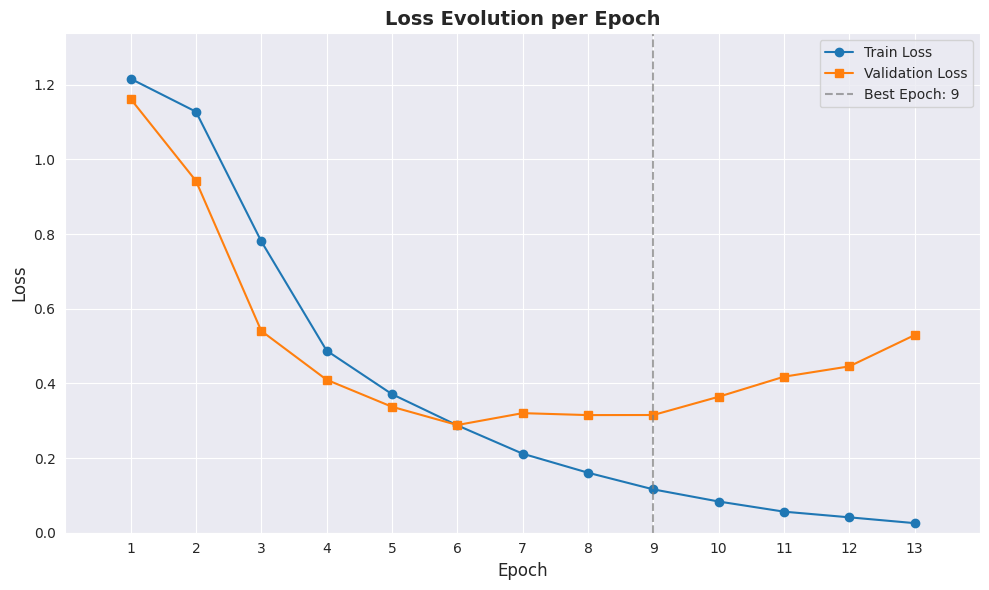

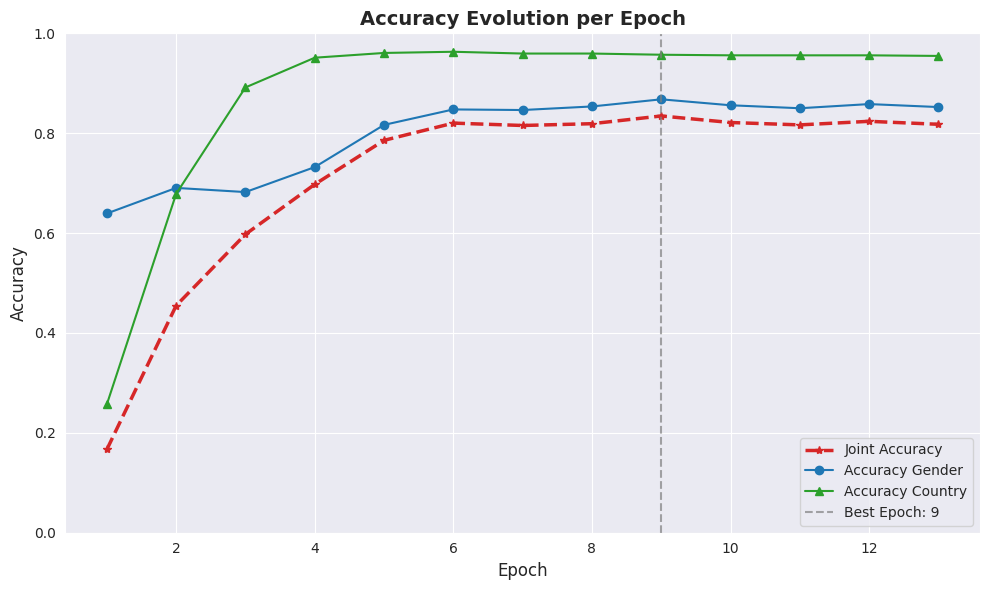

In [ ]:
# Load the model from a checkpoint.
trainer = Trainer.load_model_from_checkpoint('/trained_model/checkpoint.pth', device = device, train_dataset = train_dataset)
model = trainer.model
model.eval()
trainer.print_training_summary()
trainer.plot_loss()
trainer.plot_accuracy()

## **5.1.- Evaluación.**

>La clase *Evaluation* se define para evaluar el desempeño del modelo multitarea sobre un conjunto de datos. Permite generar métricas clave como loss, accuracies y reportes de clasificación detallados para las tareas de género y país, además de visualizar las matrices de confusión para ambas. Esta clase resume la evaluación de manera integral y gráfica, facilitando la interpretación de los resultados del modelo.

Evaluating on Evaluation Set:


Evaluation... : 100%|██████████| 105/105 [01:14<00:00,  1.40it/s]


Loss             : 0.2996
Joint Accuracy   : 0.8345
Accuracy Gender  : 0.8679
Accuracy Country : 0.9571

 Classification Report (Gender):
              precision    recall  f1-score   support

      female       0.88      0.86      0.87       420
        male       0.86      0.88      0.87       420

    accuracy                           0.87       840
   macro avg       0.87      0.87      0.87       840
weighted avg       0.87      0.87      0.87       840


 Classification Report (Country):
              precision    recall  f1-score   support

   argentina       0.93      0.98      0.96       120
       chile       0.97      0.97      0.97       120
    colombia       0.97      0.97      0.97       120
      mexico       0.97      0.96      0.97       120
        peru       0.93      0.92      0.92       120
       spain       0.94      0.96      0.95       120
   venezuela       0.97      0.94      0.96       120

    accuracy                           0.96       840
   macro avg

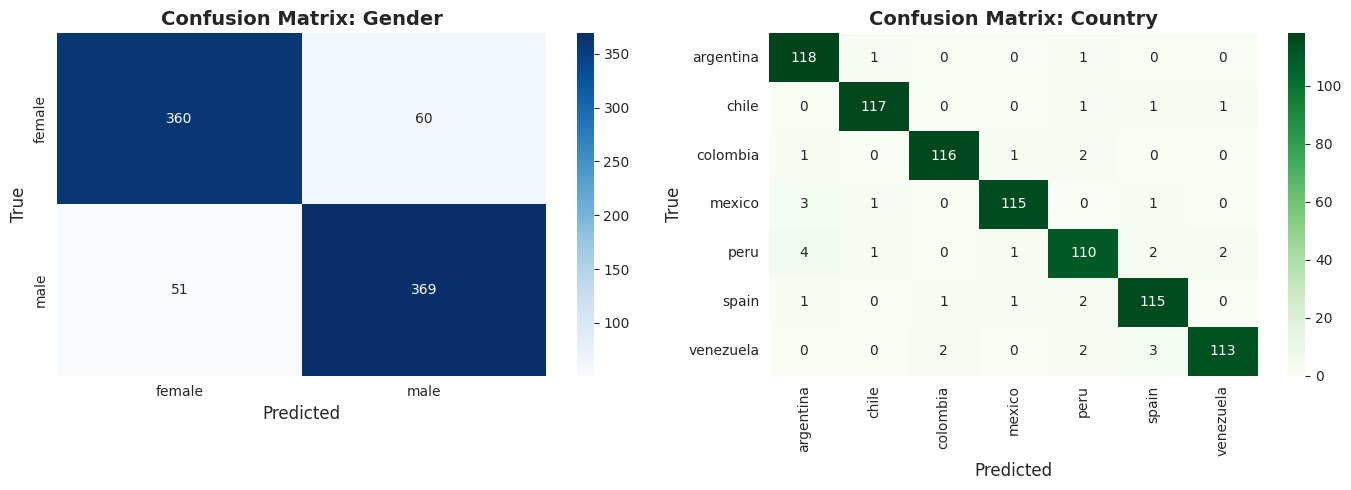

In [ ]:
class Evaluation:
    
    @staticmethod
    def plot_confusion_matrices(y_true_gender: List[int], y_pred_gender: List[int], labels_gender: List[str],
                                y_true_country: List[int], y_pred_country: List[int], labels_country: List[str]) -> None:
        """
        Generates and displays confusion matrices for gender and country predictions.

        Parameters
        ----------
        y_true_gender : List[int]
            True labels for gender.
        y_pred_gender : List[int]
            Predicted labels for gender.
        labels_gender : List[str]
            Class names for gender.
        y_true_country : List[int]
            True labels for country.
        y_pred_country : List[int]
            Predicted labels for country.
        labels_country : List[str]
            Class names for country.
        """
        fig, axes = plt.subplots(1, 2, figsize = (14, 5))

        # Gender confusion matrix
        cm_gender = confusion_matrix(y_true_gender, y_pred_gender)
        sns.heatmap(cm_gender, annot = True, fmt = 'd', cmap = 'Blues',
                    xticklabels = labels_gender, yticklabels = labels_gender, ax = axes[0])
        axes[0].set_title("Confusion Matrix: Gender", fontsize = 14, weight = 'bold')
        axes[0].set_xlabel("Predicted", fontsize = 12)
        axes[0].set_ylabel("True", fontsize = 12)

        # Country confusion matrix
        cm_country = confusion_matrix(y_true_country, y_pred_country)
        sns.heatmap(cm_country, annot = True, fmt = 'd', cmap = 'Greens',
                    xticklabels = labels_country, yticklabels = labels_country, ax = axes[1])
        axes[1].set_title("Confusion Matrix: Country", fontsize = 14, weight = 'bold')
        axes[1].set_xlabel("Predicted", fontsize = 12)
        axes[1].set_ylabel("True", fontsize = 12)

        plt.tight_layout()
        plt.show()

    @staticmethod
    def evaluate_dataset(trainer: Trainer, dataloader: DataLoader) -> dict:
        """
        Evaluates the provided dataset using a trained Trainer instance. This method:
            - Runs evaluation on the dataset.
            - Prints key performance metrics, including loss and accuracies.
            - Prints detailed classification reports for gender and country.
            - Calls plot_confusion_matrices() to visualize confusion matrices.

        Parameters
        ----------
        trainer : Trainer
            A trained Trainer instance with an attached model.
        dataloader : DataLoader
            DataLoader providing the evaluation dataset.

        Returns
        -------
        dict
            Dictionary containing evaluation results, including:
            - 'loss_val', 'joint_accuracy', 'accuracy_gender', 'accuracy_country'
            - 'targets_gender', 'preds_gender'
            - 'targets_country', 'preds_country'
            - 'scores_gender', 'scores_country'
        """
        print(f"Evaluating on Evaluation Set:")
        results = trainer.eval_model(dataloader)

        # Print metrics
        print(f"Loss             : {results['loss_val']:.4f}")
        print(f"Joint Accuracy   : {results['joint_accuracy']:.4f}")
        print(f"Accuracy Gender  : {results['accuracy_gender']:.4f}")
        print(f"Accuracy Country : {results['accuracy_country']:.4f}")

        # Recover class labels
        labels_gender = [label for label, _ in sorted(trainer.train_dataset.gender_to_id.items(), key = lambda x: x[1])]
        labels_country = [label for label, _ in sorted(trainer.train_dataset.country_to_id.items(), key = lambda x: x[1])]

        print("\n Classification Report (Gender):")
        print(classification_report(results['targets_gender'], results['preds_gender'], target_names = labels_gender))

        print("\n Classification Report (Country):")
        print(classification_report(results['targets_country'], results['preds_country'], target_names = labels_country))

        Evaluation.plot_confusion_matrices(
            results['targets_gender'], results['preds_gender'], labels_gender,
            results['targets_country'], results['preds_country'], labels_country
        )

        return results

results = Evaluation.evaluate_dataset(trainer, val_loader)

## **5.2.- Creación del archivo .csv.**

> La clase *TestPredictor* se encarga de realizar predicciones finales sobre los datos de prueba usando un modelo previamente entrenado. Toma los batches, genera las predicciones de género y país por usuario, asegura que los resultados queden ordenados según el archivo de referencia, y guarda las salidas en un archivo CSV compatible con los formatos de evaluación. Es la pieza final del pipeline para producir resultados listos para entrega o análisis.

In [ ]:
class TestPredictor:
    def __init__(self, trainer: Trainer, dataset: Dataset, dataloader: DataLoader):
        """
        TestPredictor is a helper class for generating predictions on a test dataset. It:
            - Iterates over a dataset using batching.
            - Passes inputs through a trained model.
            - Maps predicted class indices back to human-readable labels (gender, country).
            - Saves predictions in a CSV format compatible with submission or evaluation.

        Parameters
        ----------
        trainer : Trainer
            Trainer object containing the trained model and device information.
        dataset : Dataset
            Test dataset, expected to provide (inputs, user_id) per item.
        dataloader : DataLoader
            DataLoader to define batch size and control iteration.
        """
        self.model = trainer.model
        self.dataset = dataset
        self.dataloader = dataloader
        self.device = trainer.device
        self.id_to_gender = dataset.id_to_gender
        self.id_to_country = dataset.id_to_country
        self.user_id_order = self.load_test_user_order()
        self.predictions = self.predict()

    def load_test_user_order(self, truth_file_path: str = '/content/drive/MyDrive/data/es_test/truth_order.txt') -> List[str]:
        """
        Loads the list of user IDs in the order specified by the provided truth file.

        Parameters
        ----------
        truth_file_path : str
            Path to the file containing user IDs in submission order.
            Each line should have the format: user_id::: (without labels).

        Returns
        -------
        List[str]
            Ordered list of user IDs.
        """
        user_ids = []
        with open(truth_file_path, 'r', encoding = 'utf-8') as f:
            for line in f:
                user_id = line.strip().split(":::")[0]
                user_ids.append(user_id)
        return user_ids

    def predict(self) -> List[Tuple[str, str]]:
        """
        Generates predictions for all users in the test dataset. This method:
            - Collects batches manually from the dataset.
            - Runs the model in evaluation mode without gradient computation.
            - Extracts predicted labels for gender and country.
            - Maps predicted indices back to their original string labels.
            - Stores the predictions as a list of (user_id, "gender:::country") tuples.

        Returns
        -------
        List[Tuple[str, str]]
            List of tuples where each tuple is (user_id, "gender:::country").
        """
        self.model.eval()
        predictions = []

        with torch.no_grad():
            for batch_start in tqdm(range(0, len(self.dataset), self.dataloader.batch_size), desc = "Predicting...", colour = "cyan"):
                batch_data = [self.dataset[i] for i in range(batch_start, min(batch_start + self.dataloader.batch_size, len(self.dataset)))]

                batch_input_ids, batch_attn_masks, batch_tfidf, batch_user_stats = [], [], [], []
                user_ids_batch = []

                for inputs, user_id in batch_data:
                    batch_input_ids.append(inputs['input_ids'])
                    batch_attn_masks.append(inputs['attention_mask'])
                    batch_tfidf.append(inputs['tfidf'])
                    batch_user_stats.append(inputs['user_stats'])
                    user_ids_batch.append(user_id)

                input_ids = pad_sequence(batch_input_ids, batch_first = True, padding_value = 0).to(self.device)
                attention_mask = pad_sequence(batch_attn_masks, batch_first = True, padding_value = 0).to(self.device)
                tfidf_tensor = torch.stack(batch_tfidf).to(self.device)
                user_stats_tensor = torch.stack(batch_user_stats).to(self.device)

                inputs_batch = {
                    'input_ids': input_ids,
                    'attention_mask': attention_mask,
                    'tfidf': tfidf_tensor,
                    'user_stats': user_stats_tensor
                }

                logits_gender, logits_country = self.model(inputs_batch)

                preds_gender = logits_gender.argmax(dim = 1).cpu().tolist()
                preds_country = logits_country.argmax(dim = 1).cpu().tolist()

                for user_id, pred_g, pred_c in zip(user_ids_batch, preds_gender, preds_country):
                    label_gender = self.id_to_gender[pred_g]
                    label_country = self.id_to_country[pred_c]
                    predictions.append((user_id, f"{label_gender}:::{label_country}"))

        return predictions

    def save_predictions_csv(self, output_file: str) -> None:
        """
        Saves the generated predictions to a CSV file in the required format. The output CSV has two columns:
            - Id (integer index following the user order from the truth file).
            - Gender:::Nationality (string label in the format "gender:::country").

        Parameters
        ----------
        output_file : str
            Path where the predictions CSV will be saved.
        """
        prediction_dict = {user_id: label for user_id, label in self.predictions}

        with open(output_file, mode = 'w', newline = '', encoding = 'utf-8') as f:
            writer = csv.writer(f)
            writer.writerow(["Id", "Gender:::Nationality"])
            for idx, user_id in enumerate(self.user_id_order):
                label = prediction_dict.get(user_id, "_:::_") 
                writer.writerow([idx, label])

output_file = "predictions.csv"
predictor = TestPredictor(
    trainer    = trainer,
    dataset    = test_dataset,
    dataloader = test_loader,
)
predictor.save_predictions_csv(output_file = output_file)

Predicting...: 100%|██████████| 350/350 [04:04<00:00,  1.43it/s]


## **5.3.- Visualización de resultados.**

>Estas funciones permiten cargar las predicciones generadas por el modelo desde un archivo CSV, transformarlas en un diccionario y un DataFrame para análisis posterior, y visualizar gráficamente la distribución de usuarios predichos por género y país. Esta etapa es clave para realizar un chequeo rápido del balance y las tendencias en las predicciones del modelo antes de entregarlas o analizarlas más a fondo.

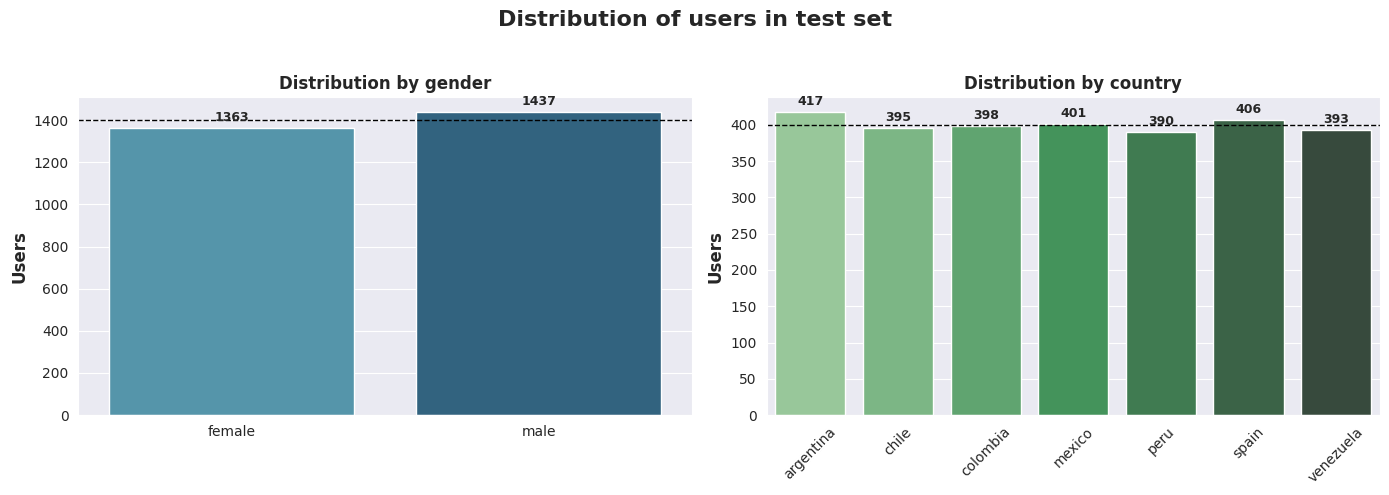

In [ ]:
def plot_predictions_distribution(output_file: str) -> None:
    """
    Plots the distribution of predicted gender and country labels from a CSV output file. This function:
        - Reads the prediction CSV (with columns "user_id" and "gender:::country").
        - Splits the combined label into separate gender and country columns.
        - Counts the number of users per gender and per country.
        - Creates two side-by-side bar plots:
            • Left: Distribution by gender.
            • Right: Distribution by country.
        - Annotates each bar with its count.
        - Draws horizontal reference lines (1400 for gender, 400 for country).

    Parameters
    ----------
    output_file : str
        Path to the CSV file containing the predictions. The file should have no header and contain:
            - Column 1: user_id.
            - Column 2: label in the format "gender:::country".
    """
    def annotate_bars(ax):
        for bar in ax.patches:
            height = bar.get_height()
            if height > 0:
                ax.annotate(f'{int(height)}', xy = (bar.get_x() + bar.get_width() / 2, height), xytext = (0,3),
                            textcoords = 'offset points', ha = 'center', va = 'bottom', fontsize = 9, weight = 'bold')

    # Read the predictions CSV file.
    df = pd.read_csv(output_file, header = None, names = ["user_id", "label"], skiprows = 1)
    df[['gender', 'country']] = df['label'].str.split(':::', expand = True)

    # Count occurrences for gender and country.
    gender_counts = df["gender"].value_counts().reindex(["female", "male"])
    country_order = sorted(df["country"].unique())
    country_counts = df["country"].value_counts().reindex(country_order)

    # Create the plots.
    fig, axs = plt.subplots(1, 2, figsize = (14,5))
    fig.suptitle('Distribution of users in test set', fontsize = 16, weight = 'bold')

    # Graph for gender.
    sns.barplot(x = gender_counts.index, y = gender_counts.values, hue = gender_counts.index, ax = axs[0], palette = "YlGnBu_d")
    axs[0].axhline(y = 1400, color = 'k', linestyle = '--', linewidth = 1)
    axs[0].set_title("Distribution by gender", fontsize = 12, weight = 'bold')
    axs[0].set_ylabel("Users", fontsize = 12, weight = 'bold')
    axs[0].set_xlabel("",fontsize = 12, weight = 'bold')
    annotate_bars(axs[0])

    # Graph for country.
    sns.barplot(x = country_counts.index, y = country_counts.values, hue = country_counts.index, ax = axs[1], palette = 'Greens_d')
    axs[1].axhline(y = 400, color = 'k', linestyle = '--', linewidth = 1)
    axs[1].set_title("Distribution by country", fontsize = 12, weight = 'bold')
    axs[1].set_ylabel("Users", fontsize = 12, weight = 'bold')
    axs[1].set_xlabel("", fontsize = 12, weight = 'bold')
    axs[1].tick_params(axis = 'x', rotation = 45)
    annotate_bars(axs[1])

    plt.tight_layout(rect = [0, 0, 1, 0.95])
    plt.show()

plot_predictions_distribution(output_file)

# **Referencias**
<a id="refs"></a>

[1] Pérez, J. M., Furman, D. A., Alonso Alemany, L., & Luque, F. (2022). *RoBERTuito: a pre-trained language model for social media text in Spanish*. arXiv:2111.09453. https://arxiv.org/abs/2111.09453